# 09 — Full Byzantine Swarm: Composition

Everything from notebooks 01–08, wired together. This is `examples/unified_demo.py` decomposed into cells: build the swarm → step the loop → inject attacks → render the result. The same orchestration primitives in `specter.demo` drive both the pygame demo and this notebook.

**Final hardware-handover artifact:** the ABC-seam diagram below identifies which boxes a TurtleBot4 / Crazyflie+UWB integrator subclasses (per ADR 0006).

**Appendix:** rerun the same composition under `Sros2Bus` if `rclpy` is installed.

## Operator question

**Can the swarm survive when everything goes wrong at once?**

Every previous notebook taught one layer in isolation: envelopes,
identity, Beta math, voting, sim, SLAM, map merge. This notebook is
where they compose. The same demonstrator that runs in
`examples/unified_demo.py` is sliced into cells here so the
hardware-integration handover (the ABC-seam diagram below) can be read
alongside the actual wiring.

In the React Workshop Console the equivalent composition surfaces
across multiple lessons rather than in one big finale — the rail's
L08 (`cop_corruption_full`) is the closest single scene to "everything
at once," running a 4-way map-layer attack on top of a Tier 1 range
lie. The Python composition here is broader: it includes the SLAM
trunk and the SROS2 transport-swap appendix, neither of which the rail
demonstrates.


## ABC-seam diagram (hardware-integration spec)

![ABC seams](../docs/abc_seams.svg)

Subclass each `<< PORT >>` box. Other boxes stay unchanged. The trust + SLAM + map-merger logic is bus-agnostic — same code runs over `InProcessBus` (this notebook), `LossyBus` (radio realism), or `Sros2Bus` (real DDS, appendix below).

In [1]:
%matplotlib inline
import os
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(_root)
from specter.demo import build_swarm, snapshot, step, apply_attack
from specter.viz.notebook import world_figure, reputation_sparkline

## Build a swarm. 4 agents, four_agents_corridor.

`build_swarm` returns a `SwarmState` that holds the entire wired pipeline: identities, roster, revocation, attestation, evaluators, replays, SLAM, mergers, bus, telemetry, and per-agent reputation traces. `step()` advances the sim one tick. `apply_attack()` mutates state in place to inject Byzantine behavior.

In [2]:
state = build_swarm('scenarios/four_agents_corridor.yaml')
print(f'agents: {state.agent_ids}')
print(f'bus:    {state.bus_label}')
print(f'viewer: {state.viewer_id}')

agents: ['alpha', 'bravo', 'charlie', 'delta']
bus:    INPROC
viewer: alpha


## Run 30 ticks honest, then inject one pose-liar and one bad-key compromise

**Read this against ADR 0015.** The `swap_key` (bad-key) attack on bravo produces immediate `bad_signature` rejections — bravo's rep drops fast. The `pose_lie` attack on alpha is now **a trust-layer no-op**: alpha lies only about its own self-pose, not about beacon ranges, so the range-only voting layer has nothing to react to. Alpha's rep stays near 1.0. This is the *correct* outcome — pose lies belong to the map-merger (notebook 07), not the trust path.

As a free side-effect of the same fix: the four-agents-corridor scenario used to collapse honest rotating peers (bravo and delta) to rep ≈ 0.23 under the old world-absolute voting because SLAM drift entered the trust path. That regression is now CI-gated at any N by `tests/eval/test_scale.py`.

In [3]:
# Honest warm-up
for _ in range(30):
    step(state)

# Inject attacks
ok1, who1 = apply_attack(state, 'pose_lie', target='alpha')
ok2, who2 = apply_attack(state, 'swap_key', target='bravo')
print(f'attacks injected: pose_lie→{who1}  swap_key→{who2}')

# Run 30 more ticks under attack
for _ in range(30):
    step(state)

snap = snapshot(state)
print(f'tick={snap.tick_count}  bad={snap.bad_agents}  lying={snap.lying_agents}')
print('viewer reputations:')
for peer, rep in sorted(snap.viewer_reputation.items()):
    flag = '!' if peer in snap.bad_agents | snap.lying_agents else ' '
    print(f'  {flag} {peer:8s}  rep={rep:.3f}')

attacks injected: pose_lie→alpha  swap_key→bravo


tick=60  bad=frozenset({'bravo'})  lying=frozenset({'alpha'})
viewer reputations:
  ! alpha     rep=1.000
  ! bravo     rep=0.449
    charlie   rep=0.985
    delta     rep=0.985


## Render the world (after attacks) + the viewer's α/β trajectory over the last 10 s

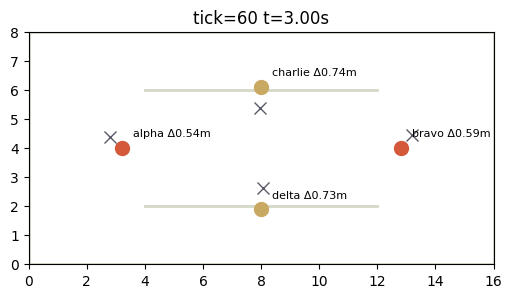

In [4]:
fig = world_figure(snap)

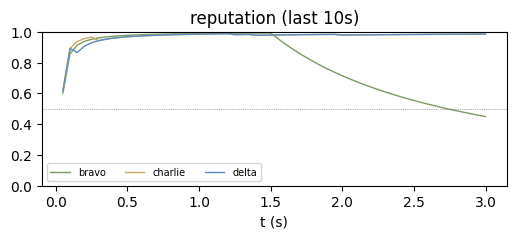

In [5]:
peers_for_history = [a for a in state.agent_ids if a != state.viewer_id]
fig = reputation_sparkline(state.rep_traces[state.viewer_id], peers_for_history, window_s=10.0)

## Claim: full-stack composition holds

bravo (compromised — swap_key) crosses the 0.4 detection threshold by the end of the 60-tick run via `bad_signature` rejections. alpha (pose-lying) stays near 1.0 at the trust layer — **deliberately**, per ADR 0015: pose lies are map-merger anomalies, not trust anomalies. The honest peers stay near 1.0. Map merging runs every 10 ticks for the viewer; the merged grid is in `state.merged_grids[state.viewer_id]`, and the misaligned occupancy votes from alpha's lying pose are what `OccupancyMapMerger` weights down via `peer_weights`.

**Audited by:** `examples/unified_demo.py` (the live showcase, same orchestration primitives) + the entire `tests/eval/` battery + `tests/eval/test_scale.py` (architectural property at any N).

## Appendix: rerun the same composition under SROS2 (if rclpy installed)

The same `build_swarm` API takes `bus_choice='sros2'` to ship envelopes through real DDS. Hardware integrators run this section to confirm detection survives the transport swap (within `2 × baseline + 5` ticks per ADR 0011).

If `rclpy` isn't installed, this cell prints an install hint and skips.

In [6]:
try:
    import rclpy  # noqa: F401
    have_rclpy = True
except ImportError:
    have_rclpy = False

if not have_rclpy:
    print('rclpy not installed.')
    print('Install ROS2 + rclpy and rerun this cell to validate the SROS2 transport swap.')
    print('  Reference: docs/HARDWARE_READINESS.md and ADR 0011')
else:
    state2 = build_swarm('scenarios/four_agents_corridor.yaml', bus_choice='sros2')
    print(f'bus: {state2.bus_label}')
    for _ in range(20):
        step(state2)
    apply_attack(state2, 'pose_lie', target='alpha')
    for _ in range(20):
        step(state2)
    snap2 = snapshot(state2)
    print(f'SROS2 tick={snap2.tick_count}  alpha rep = {snap2.viewer_reputation.get("alpha"):.3f}')

rclpy not installed.
Install ROS2 + rclpy and rerun this cell to validate the SROS2 transport swap.
  Reference: docs/HARDWARE_READINESS.md and ADR 0011


## Limit

* **Phase-1 hardware criteria** in `docs/HARDWARE_READINESS.md` requires the same battery to pass on Gazebo + real ROS2/DDS. Until that lands, every claim here is conditional on the simulator's noise model matching real radios.
* **Pose correction** is out of scope per ADR 0010. Loop closure detection ships; downstream integrates a pose-graph optimizer (Cartographer / SLAM Toolbox) on real hardware.
* **Hardware-attestation provider is mock**. A thief with a stolen signing key still bypasses the gate on the device they stole from. Phase-4 problem.

All shipped capabilities are exercised here. Anything missing from the audit surface lives in `docs/HARDWARE_READINESS.md` as the next slice.